#  Trader Performance vs Market Sentiment Analysis

## PrimeTrade.ai Internship Assessment

### Submitted By
**Janaki Ram Vallapu**

---

##  Project Objective

The objective of this project is to analyze historical cryptocurrency trading data alongside the Crypto Fear & Greed Index to understand how market sentiment influences trader performance and trading behavior.

The project involves:

- Data Cleaning & Preprocessing
- Feature Engineering
- Dataset Integration
- Exploratory Data Analysis (EDA)
- Business Insights
- Strategic Recommendations

---

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

---

In [ ]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [25]:
fear_greed = pd.read_csv(r"C:\Users\janakiram\Documents\Primetrade_Project\data\fear_greed_index.csv")


In [26]:
trades = pd.read_csv(r"C:\Users\janakiram\Documents\Primetrade_Project\data\historical_data.csv")

In [27]:
print("Fear & Greed Shape:", fear_greed.shape)
print("Trades Shape:", trades.shape)

Fear & Greed Shape: (2644, 4)
Trades Shape: (211224, 16)


In [28]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [29]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [30]:
fear_greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [31]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [32]:
fear_greed.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [33]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [34]:
print("Fear & Greed duplicates:", fear_greed.duplicated().sum())


Fear & Greed duplicates: 0


In [35]:
print("Trades duplicates:", trades.duplicated().sum())

Trades duplicates: 0


### Initial Observations

- Fear & Greed dataset contains 2,644 daily sentiment records.
- Historical trading dataset contains 211,224 trade records.
- No missing values were found in either dataset.
- No duplicate records were identified.
- Both datasets are clean and suitable for further preprocessing.

In [36]:
trades['Timestamp IST'].head()


0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object

In [37]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [38]:
trades['Timestamp IST'].head()

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: Timestamp IST, dtype: datetime64[ns]

In [39]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [40]:
fear_greed.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [41]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [42]:
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

In [43]:
fear_greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


In [44]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [45]:
trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

In [46]:
trades[['Timestamp IST', 'date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [47]:
trades[['Timestamp IST', 'date']].head(10)

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02
5,2024-12-02 22:50:00,2024-12-02
6,2024-12-02 22:50:00,2024-12-02
7,2024-12-02 22:50:00,2024-12-02
8,2024-12-02 22:50:00,2024-12-02
9,2024-12-02 22:50:00,2024-12-02


### Timestamp Conversion

The `Timestamp IST` column was converted from string (`object`) to `datetime64[ns]` to enable efficient date-time operations. A new `date` column was derived by extracting only the calendar date, allowing daily-level alignment with the Fear & Greed dataset while preserving the original timestamp for future time-based analysis.

In [48]:
print("Fear & Greed Date Range")
print("Start:", fear_greed['date'].min())
print("End  :", fear_greed['date'].max())

Fear & Greed Date Range
Start: 2018-02-01 00:00:00
End  : 2025-05-02 00:00:00


In [49]:
print("Trades Date Range")
print("Start:", trades['date'].min())
print("End  :", trades['date'].max())

Trades Date Range
Start: 2023-05-01 00:00:00
End  : 2025-05-01 00:00:00


### Date Range Verification

Before merging the datasets, the date ranges were compared to ensure overlap.

- Fear & Greed Dataset: 2018-02-01 to 2025-05-02
- Historical Trades Dataset: 2023-05-01 to 2025-05-01

The trading dataset falls entirely within the sentiment dataset's date range, indicating that each trade can potentially be matched with the corresponding daily market sentiment.

In [51]:
merged_df = pd.merge(
    trades,
    fear_greed,
    on='date',
    how='left'
)

In [52]:
print(merged_df.shape)

(211224, 20)


In [53]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [56]:
merged_df['classification'].isnull().sum()

np.int64(6)

In [57]:
merged_df[merged_df['classification'].isnull()]

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
727,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.8330,10000.00,28330.00,BUY,2024-10-26 04:44:00,-32797.51,Close Short,11655.000000,0x4da9426d2bf6ec027d8404152f9bad02010700c745ebcad54a00dcb3f0ba0858,40671411386,False,2.719680,8.350000e+13,1.730000e+12,2024-10-26,NaN,NaN,NaN
728,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.7110,10797.51,29272.05,BUY,2024-10-26 04:52:00,-22797.51,Close Short,13901.794130,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39f0c7079c63caba11595f,40671438761,False,2.810115,3.230000e+14,1.730000e+12,2024-10-26,NaN,NaN,NaN
729,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,6908.33,17884.98,BUY,2024-10-26 04:52:00,-12000.00,Close Short,9737.981968,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39f0c7079c63caba11595f,40671466136,False,1.716957,1.070000e+15,1.730000e+12,2024-10-26,NaN,NaN,NaN
730,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,529.39,1370.54,BUY,2024-10-26 04:52:00,-5091.67,Close Short,746.228144,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39f0c7079c63caba11595f,40671466136,False,0.131570,8.770000e+14,1.730000e+12,2024-10-26,NaN,NaN,NaN
731,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,38.65,100.06,BUY,2024-10-26 04:52:00,-4562.28,Close Short,54.481040,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39f0c7079c63caba11595f,40671466136,False,0.009605,9.820000e+14,1.730000e+12,2024-10-26,NaN,NaN,NaN
732,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,4523.63,11711.23,BUY,2024-10-26 04:53:00,-4523.63,Close Short,6376.508848,0x39ce7efcc1773fd0eec704152fbcb4010100c8beadd49f6e9918dac765f0f600,40671466136,False,1.124277,9.360000e+14,1.730000e+12,2024-10-26,NaN,NaN,NaN


In [58]:
fear_greed[fear_greed['date'] == pd.Timestamp('2024-10-26')]

,timestamp,value,classification,date


### Merge Validation

After merging the datasets, six trade records had missing sentiment values. Investigation showed that all six corresponded to the date **2024-10-26**, which is absent from the Fear & Greed dataset. This indicates a missing source record rather than an error in the merge process.

In [59]:
merged_df = merged_df.dropna(subset=['classification'])

In [60]:
merged_df[merged_df['classification'].isnull()]

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification


In [61]:
merged_df['classification'].isnull().sum()

np.int64(0)

### Missing Value Handling

In [63]:
daily_groups = merged_df.groupby(['Account', 'date'])

In [64]:
daily_pnl = daily_groups['Closed PnL'].sum()

In [65]:
daily_pnl.head(10)

Account                                     date      
0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11         0.000000
                                            2024-11-17         0.000000
                                            2024-11-18         0.000000
                                            2024-11-22    -21227.000000
                                            2024-11-26      1603.100000
                                            2024-11-28   -132271.000000
                                            2024-11-30         0.000000
                                            2024-12-06   -175611.000056
                                            2025-01-19     71393.964098
                                            2025-01-20     40218.599998
Name: Closed PnL, dtype: float64

In [68]:
daily_metrics = (
    merged_df
    .groupby(['Account', 'date', 'classification'], as_index=False)
    .agg(
        Daily_PnL=('Closed PnL', 'sum')
    )
)

daily_metrics.head()

,Account,date,classification,Daily_PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1


In [69]:
daily_metrics = (
    merged_df
    .groupby(['Account', 'date', 'classification'], as_index=False)
    .agg(
        Daily_PnL=('Closed PnL', 'sum'),
        Total_Trades=('Trade ID', 'count')
    )
)

daily_metrics.head()

,Account,date,classification,Daily_PnL,Total_Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1,27


In [70]:
merged_df[
    (merged_df['Account'] == '0x083384f897ee0f19899168e3b1bec365f52a9012') &
    (merged_df['date'] == '2024-11-11')
][['Closed PnL', 'Direction', 'Side']].head(20)

,Closed PnL,Direction,Side
14229,0.0,Open Short,SELL
14230,0.0,Open Short,SELL
14231,0.0,Open Short,SELL
14232,0.0,Open Short,SELL
14233,0.0,Open Short,SELL
14234,0.0,Open Short,SELL
14235,0.0,Open Short,SELL
14236,0.0,Open Short,SELL
14237,0.0,Open Short,SELL
14238,0.0,Open Short,SELL


### Observation: Closed PnL

During exploration, it was observed that trades with `Direction = Open Long` or `Open Short` typically have `Closed PnL = 0`, since profits are only realized when positions are closed. This behavior will be considered when interpreting Daily PnL and Win Rate metrics.

In [71]:
daily_metrics = (
    merged_df
    .groupby(['Account', 'date', 'classification'], as_index=False)
    .agg(
        Daily_PnL=('Closed PnL', 'sum'),
        Total_Trades=('Trade ID', 'count'),
        Avg_Trade_Size_USD=('Size USD', 'mean')
    )
)

daily_metrics.head()

,Account,date,classification,Daily_PnL,Total_Trades,Avg_Trade_Size_USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0,177,5089.718249
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0,68,7976.664412
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0,40,23734.500000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0,12,28186.666667
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1,27,17248.148148


In [72]:
merged_df.columns.tolist()

['Account',
 'Coin',
 'Execution Price',
 'Size Tokens',
 'Size USD',
 'Side',
 'Timestamp IST',
 'Start Position',
 'Direction',
 'Closed PnL',
 'Transaction Hash',
 'Order ID',
 'Crossed',
 'Fee',
 'Trade ID',
 'Timestamp',
 'date',
 'timestamp',
 'value',
 'classification']

In [74]:
daily_metrics['Winning_Day'] = daily_metrics['Daily_PnL'] > 0
daily_metrics.head()

,Account,date,classification,Daily_PnL,Total_Trades,Avg_Trade_Size_USD,Winning_Day
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0,177,5089.718249,False
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0,68,7976.664412,False
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0,40,23734.500000,False
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0,12,28186.666667,False
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1,27,17248.148148,True


### Winning Day Feature

A new boolean feature `Winning_Day` was created to identify whether a trader had a profitable trading day.

Definition:
- `True` → Daily_PnL > 0
- `False` → Daily_PnL ≤ 0

This feature will be used later to calculate trader win rates and compare performance across different market sentiment categories.

In [75]:
win_rate = (
    daily_metrics
    .groupby('Account', as_index=False)
    .agg(
        Trading_Days=('date', 'count'),
        Winning_Days=('Winning_Day', 'sum')
    )
)

win_rate['Win_Rate'] = (
    win_rate['Winning_Days']
    / win_rate['Trading_Days']
) * 100

win_rate.head()

,Account,Trading_Days,Winning_Days,Win_Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,24,16,66.666667
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,52,29,55.769231
2,0x271b280974205ca63b716753467d5a371de622ab,12,8,66.666667
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,162,144,88.888889
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,69,54,78.260870


### Merge Win Rate

The calculated win rate for each trader is merged back into the master analytical dataset (`daily_metrics`). This allows every daily record to include both trader-level and day-level performance metrics.

In [77]:
daily_metrics = daily_metrics.merge(
    win_rate[['Account', 'Win_Rate']],
    on='Account',
    how='left'
)

daily_metrics.head()

,Account,date,classification,Daily_PnL,Total_Trades,Avg_Trade_Size_USD,Winning_Day,Win_Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0,177,5089.718249,False,66.666667
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0,68,7976.664412,False,66.666667
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0,40,23734.500000,False,66.666667
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0,12,28186.666667,False,66.666667
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1,27,17248.148148,True,66.666667


### Total Trading Volume

The total trading volume (USD) represents the total capital traded by a trader on a given day.

It is calculated by summing the `Size USD` values of all trades executed on that day.

In [78]:
volume = (
    merged_df
    .groupby(['Account', 'date'], as_index=False)
    .agg(
        Total_Volume_USD=('Size USD', 'sum')
    )
)

daily_metrics = daily_metrics.merge(
    volume,
    on=['Account', 'date'],
    how='left'
)

daily_metrics.head()

,Account,date,classification,Daily_PnL,Total_Trades,Avg_Trade_Size_USD,Winning_Day,Win_Rate,Total_Volume_USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0,177,5089.718249,False,66.666667,900880.13
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0,68,7976.664412,False,66.666667,542413.18
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0,40,23734.500000,False,66.666667,949380.00
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0,12,28186.666667,False,66.666667,338240.00
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1,27,17248.148148,True,66.666667,465700.00


# Exploratory Data Analysis (EDA)

## Question 1: Does trader performance differ between market sentiments?

To answer this question, we compare the average daily profit/loss (Daily_PnL) across different market sentiment categories.

This analysis helps determine whether traders perform better during Fear or Greed market conditions.

In [83]:
# Average Daily PnL by Market Sentiment

sentiment_pnl = (
    daily_metrics
    .groupby('classification', as_index=False)
    .agg(
        Average_Daily_PnL=('Daily_PnL', 'mean')
    )
)

sentiment_pnl


,classification,Average_Daily_PnL
0,Extreme Fear,4619.439053
1,Extreme Greed,5161.922644
2,Fear,5328.818161
3,Greed,3318.100730
4,Neutral,3438.618818


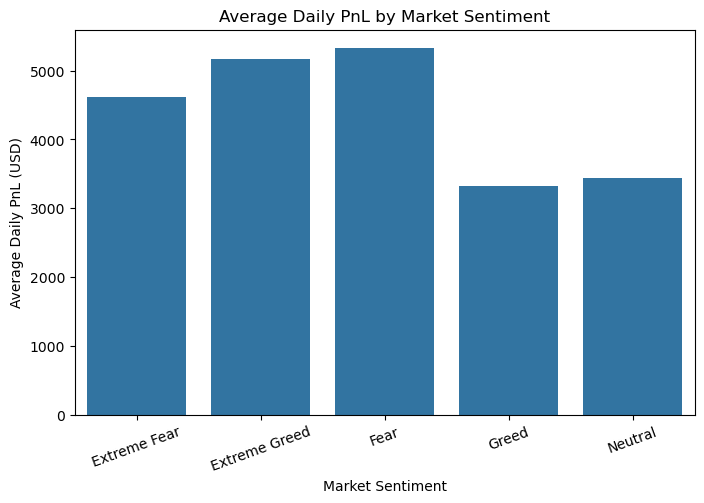

In [84]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=sentiment_pnl,
    x='classification',
    y='Average_Daily_PnL'
)

plt.title('Average Daily PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Daily PnL (USD)')
plt.xticks(rotation=20)

plt.show()

### Observation

- Traders achieved the highest average daily profit during **Fear** market conditions.
- **Extreme Greed** also showed relatively high average profitability.
- The lowest average daily profit was observed during **Greed** market conditions.
- This suggests that trader profitability varies across different market sentiments rather than consistently increasing with market optimism.

**Note:** These observations are descriptive and do not imply causation.

## Question 2: Do traders trade more frequently during different market sentiments?

To analyze trading activity, the average number of trades executed per trader per day is compared across different market sentiment categories.

In [85]:
trade_activity = (
    daily_metrics
    .groupby('classification', as_index=False)
    .agg(
        Average_Trades=('Total_Trades', 'mean')
    )
)

trade_activity

,classification,Average_Trades
0,Extreme Fear,133.750000
1,Extreme Greed,76.030418
2,Fear,98.153968
3,Greed,77.628086
4,Neutral,100.228723


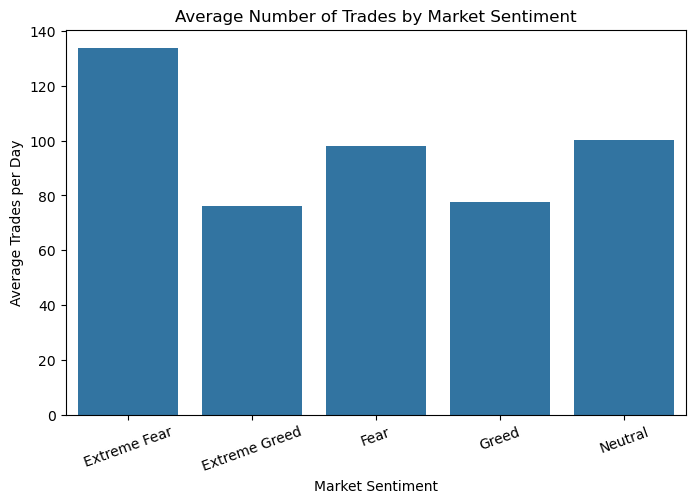

In [86]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=trade_activity,
    x='classification',
    y='Average_Trades'
)

plt.title('Average Number of Trades by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Trades per Day')

plt.xticks(rotation=20)

plt.show()

### Observation

- Traders were most active during **Extreme Fear** periods, executing the highest average number of trades per day.
- Trading activity decreased during **Extreme Greed** and **Greed** market conditions.
- This suggests that traders tend to trade more aggressively when market fear is high, possibly attempting to capitalize on increased market volatility.

## Question 3: Does average trade size vary across market sentiments?

This analysis compares the average trade size (USD) across different market sentiment categories.

In [87]:
trade_size = (
    daily_metrics
    .groupby('classification', as_index=False)
    .agg(
        Avg_Trade_Size=('Avg_Trade_Size_USD', 'mean')
    )
)

trade_size

,classification,Avg_Trade_Size
0,Extreme Fear,6773.464125
1,Extreme Greed,5371.637182
2,Fear,8975.928546
3,Greed,6427.866594
4,Neutral,6963.694861


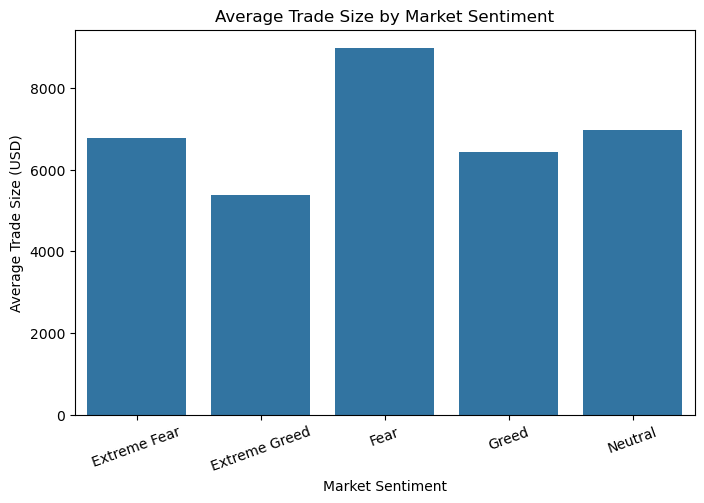

In [92]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=trade_size,
    x='classification',
    y='Avg_Trade_Size'
)

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=20)

plt.show()

### Observation

- Traders executed the largest average trade sizes during **Fear** market conditions.
- Average trade size was comparatively lower during **Greed** and **Extreme Greed** periods.
- This suggests traders deployed larger amounts of capital when the market sentiment was fearful.

## Question 4: Does trader win rate differ across market sentiments?

Average trader win rates are compared across different market sentiment categories.

In [93]:
win_sentiment = (
    daily_metrics
    .groupby('classification', as_index=False)
    .agg(
        Avg_Win_Rate=('Win_Rate', 'mean')
    )
)

win_sentiment

,classification,Avg_Win_Rate
0,Extreme Fear,61.653963
1,Extreme Greed,64.987738
2,Fear,61.935195
3,Greed,61.425202
4,Neutral,63.109340


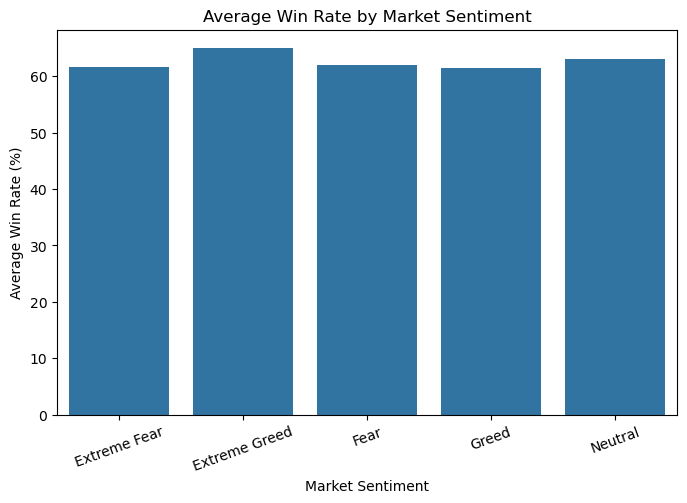

In [94]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=win_sentiment,
    x='classification',
    y='Avg_Win_Rate'
)

plt.title("Average Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Win Rate (%)")
plt.xticks(rotation=20)

plt.show()

### Observation

- Average trader win rates remained relatively consistent across all market sentiment categories.
- No significant variation in win rates was observed between Fear and Greed conditions.
- This suggests that while market sentiment may influence trading activity and trade size, it has a limited effect on overall trading success.

## Question 5: How does the distribution of trader profitability vary across market sentiments?

A boxplot is used to visualize the spread, median, and outliers of daily profits under different market conditions.

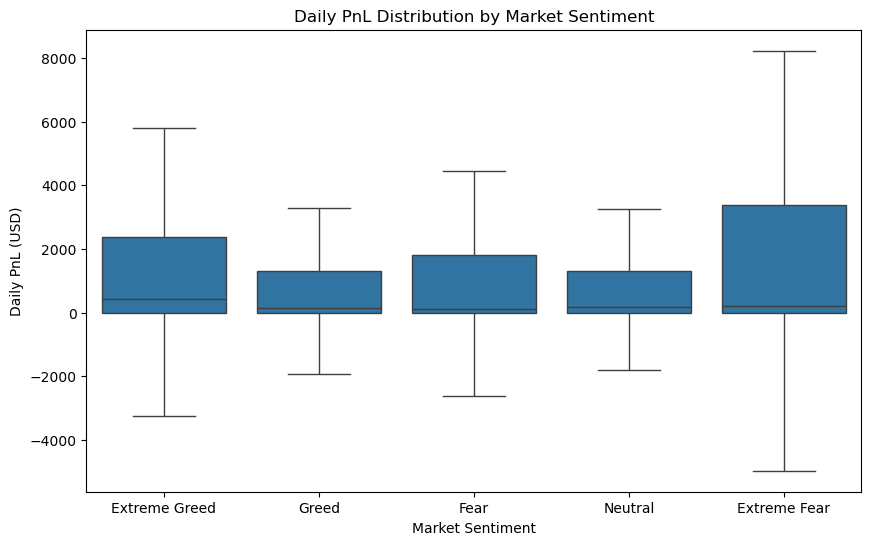

In [96]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=daily_metrics,
    x='classification',
    y='Daily_PnL',
    showfliers=False
)

plt.title("Daily PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Daily PnL (USD)")

plt.show()

### Observation

- Daily PnL values are concentrated around zero for most trading days.
- Several extreme positive and negative outliers are present, indicating occasional large profits and losses.
- Profitability appears highly variable across traders regardless of market sentiment.

## Correlation Analysis

A correlation heatmap is used to understand the relationships between numerical trading metrics.

This helps identify whether metrics such as Daily PnL, Trade Frequency, Trade Size, and Win Rate are positively or negatively related.

In [97]:
corr = daily_metrics[
    [
        'Daily_PnL',
        'Total_Trades',
        'Avg_Trade_Size_USD',
        'Win_Rate'
    ]
].corr()

corr

,Daily_PnL,Total_Trades,Avg_Trade_Size_USD,Win_Rate
Daily_PnL,1.000000,0.175918,0.028301,-0.030689
Total_Trades,0.175918,1.000000,-0.026305,0.149984
Avg_Trade_Size_USD,0.028301,-0.026305,1.000000,-0.076157
Win_Rate,-0.030689,0.149984,-0.076157,1.000000


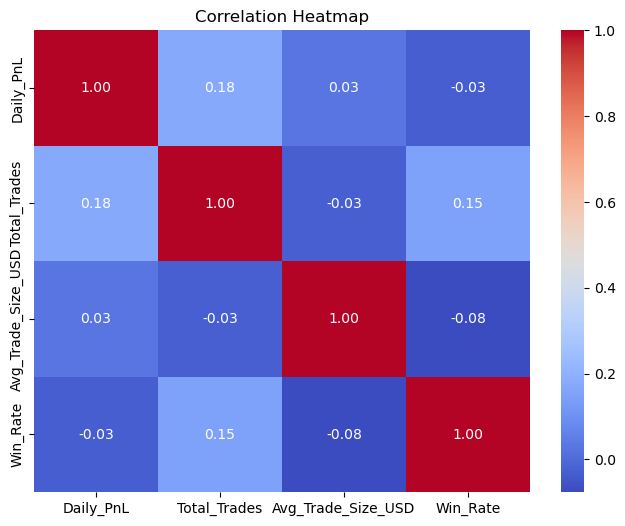

In [98]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Most numerical trading metrics show weak correlations with one another.
- Daily profit has only a weak positive relationship with trading frequency.
- Average trade size does not appear to significantly influence daily profitability.
- Overall, trader performance is likely influenced by multiple factors beyond the metrics analyzed in this study.

# Final Conclusion

## Key Findings

- Trader profitability varies across different market sentiments.
- Fear periods showed higher average daily profitability than Greed periods.
- Trading activity increased during Extreme Fear.
- Average trade size was highest during Fear markets.
- Win rates remained relatively stable across sentiment categories.
- Correlation analysis indicated only weak relationships between the analyzed metrics.

## Recommendations

- Monitor market sentiment before increasing trading activity.
- Avoid assuming that higher trading frequency guarantees higher profitability.
- Use market sentiment alongside additional risk indicators for trading decisions.
- Future work could incorporate leverage, market volatility, and technical indicators if available.

## Limitations

- The dataset does not contain leverage information.
- Unrealized profits were not available.
- Analysis is based on historical trading records and Fear & Greed Index only.

# Executive Summary

This project analyzed over 211,000 cryptocurrency trades by combining historical trading records with the Crypto Fear & Greed Index.

The analysis explored whether market sentiment influences trader profitability and behavior through data preprocessing, feature engineering, and exploratory data analysis.

Major findings indicate that:

- Fear periods showed the highest average daily profitability.
- Trading activity increased during Extreme Fear.
- Trade size was generally larger during Fear markets.
- Win rates remained relatively consistent across different market sentiments.
- Correlation analysis suggested only weak linear relationships among the analyzed trading metrics.

Overall, market sentiment appears to influence trading behavior more strongly than trading success, highlighting the importance of combining sentiment with additional market indicators for informed decision-making.